Q1. What is the difference between K-Means and Hierarchical Clustering? Provide a use case for each

Ans-

#K-Means Clustering

- A partition-based clustering algorithm

- You must predefine the number of clusters (K)

- Assigns each data point to the nearest cluster centroid

How it works (simple)

- Choose K

- Initialize K centroids

- Assign points to nearest centroid

- Recalculate centroids

- Repeat until convergence

Key characteristics

- Fast and scalable (good for large datasets)

- Works best with numeric data

- Assumes clusters are spherical and similar in size

- Sensitive to outliers and initial centroid selection

 Use Case - Customer Segmentation in E-commerce

Segment customers based on:

- Annual spending

- Frequency of purchases

- Average order value

- Dataset is large, numeric, and you already know how many segments you want (e.g., 5 customer types)

#Hierarchical Clustering

- Builds a tree-like structure (dendrogram)

- Does not require predefined number of clusters

Can be:

- Agglomerative (bottom-up) – most common

- Divisive (top-down)

How it works (agglomerative)

- Start with each point as its own cluster

- Merge closest clusters step by step

- Continue until one cluster remains

Key characteristics

- Computationally expensive (not ideal for very large datasets)

- Works with numeric and categorical data

- Provides multi-level clustering insights

- More interpretable via dendrogram

Use Case -  Gene Expression / Biological Data Analysis

- Cluster genes based on expression similarity

- Scientists don’t know the number of natural clusters beforehand

- Need to explore relationships at multiple levels

Q2.  Explain the purpose of the Silhouette Score in evaluating clustering algorithms?

Ans-

The Silhouette Score is used to evaluate how well a clustering algorithm has grouped data points by measuring:

How similar a data point is to its own cluster compared to other clusters

In short, it tells us:

Are clusters compact (tight)?

Are clusters well separated from each other?

For each data point, it considers two values:

1️⃣ a = Intra-cluster distance

Average distance between a point and all other points in the same cluster

Measures cluster cohesion

2️⃣ b = Nearest-cluster distance

Average distance between the point and points in the nearest neighboring cluster

Measures cluster separation

 Silhouette Formula

Silhouette Score =𝑏−𝑎 / max(𝑎,𝑏)

1. Evaluates clustering quality without labels

Perfect for unsupervised learning

No ground truth needed

2. Helps choose the optimal number of clusters (K)

Compute score for different K values

Pick K with the highest silhouette score

3. Works across clustering algorithms

K-Means

Hierarchical Clustering

DBSCAN (with caveats)
	​



Q3. What are the core parameters of DBSCAN, and how do they influence the
clustering process?

Ans-

#eps (ε – Epsilon)

What it is

The maximum distance between two points for them to be considered neighbors.

How it influences clustering

Defines the radius of the neighborhood around each point.

Controls how close points must be to form a cluster.

Effects of eps choice

- Too small → Many points labeled as noise, clusters break apart

- Too large → Different clusters may merge into one

 Interpretation:

eps decides how dense is “dense enough.”

#min_samples (or MinPts)

What it is

The minimum number of points required within an eps-neighborhood to form a dense region.

How it influences clustering

Determines whether a point is considered a core point.

Controls cluster robustness and sensitivity to noise.

Effects of min_samples choice

- Low value → More clusters, sensitive to noise

- High value → Fewer clusters, more points marked as noise

 Rule of thumb:

min_samples ≥ dimensions + 1

Common values: 4–10

| Parameter     | Main Role          | Impact                           |
|--------------|--------------------|----------------------------------|
| eps          | Neighborhood size  | Controls cluster **compactness** |
| min_samples  | Density threshold  | Controls **noise tolerance**     |
| Both together| Density definition | Decide cluster formation & shape |


Q4. Why is feature scaling important when applying clustering algorithms like K-Means and DBSCAN?

Ans-

# Distance Dominance Problem

Clustering algorithms usually use Euclidean distance.

If one feature has a larger numeric range, it will dominate the distance.

Smaller-scale features become almost irrelevant.

 - Example:

 Age: 18–60

 Annual income: ₹2,00,000–₹20,00,000

 Without scaling, income will completely overpower age in clustering.

# Impact on K-Means

Why scaling is important

- K-Means minimizes within-cluster squared distance

- Centroids are calculated using feature means

Without scaling

- Clusters are biased toward large-magnitude features

- Centroids shift incorrectly

With scaling

- All features contribute equally

- Clusters reflect true data patterns

Best practice:

- Use StandardScaler or MinMaxScaler

# Impact on DBSCAN

Why scaling is important

DBSCAN depends on:

- eps (distance radius)

- Neighborhood density

Without scaling

- eps becomes meaningless

- Dense regions may disappear or merge incorrectly

With scaling

- Density is measured consistently across features

- Noise and clusters are detected correctly

# Example Scenario

- Customer Segmentation

Features:

- Age (years)

- Spending Score (0–100)

- Income (₹)

 Without scaling:

- Income dominates

- Clusters ignore age & behavior

 With scaling:

- Balanced influence of all features

- Meaningful customer segments

Q5. What is the Elbow Method in K-Means clustering and how does it help
determine the optimal number of clusters?

Ans-

The Elbow Method is a heuristic technique used in K-Means clustering to help choose the optimal number of clusters (K) by balancing model simplicity and clustering quality.

K-Means tries to minimize Within-Cluster Sum of Squares (WCSS), also called inertia:


WCSS = ∑ i = 1 K ∑ x ∈ Ci ∥ x − μi ∥ 2


As K increases:

- WCSS always decreases

- But after a point, the improvement becomes marginal

The Elbow Method looks for that point of diminishing returns.

#How the Elbow Method Works

- Run K-Means for a range of K values (e.g., 1 to 10)
- Compute WCSS (inertia) for each K
- Plot K vs WCSS
- Identify the “elbow” point where the curve sharply bends

 That elbow is considered the optimal K.

#Why It Works

Small K → underfitting (clusters too broad)

Large K → overfitting (tiny, unnecessary clusters)

Elbow point → best trade-off between:

- Compact clusters

- Model simplicity

WCSS
│\
│ \
│  \
│   \
│    \____  ← Elbow point
│         \
└────────────── K
#Practical Example

Customer Segmentation

- Try K = 1 to 8

- Elbow observed at K = 4

- Means 4 customer segments capture most structure without overcomplicating


Q6. Generate synthetic data using make_blobs(n_samples=300, centers=4),
apply KMeans clustering, and visualize the results with cluster centers.


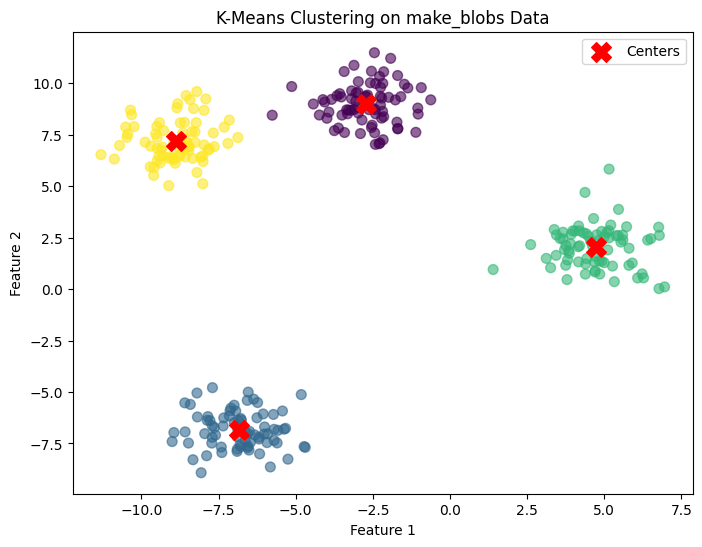

In [1]:
#Ans 6.

# Import necessary libraries
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Step 1: Generate synthetic data
X, y_true = make_blobs(n_samples=300, centers=4, random_state=42)

# Step 2: Apply KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Step 3: Plot the clustered data
plt.figure(figsize=(8,6))

# Plot data points colored by cluster assignment
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis', alpha=0.6)

# Plot cluster centers
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X', label='Centers')

plt.title("K-Means Clustering on make_blobs Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


Q7.  Load the Wine dataset, apply StandardScaler , and then train a DBSCAN
model. Print the number of clusters found (excluding noise).


In [2]:
#Ans Q7.

# Import necessary libraries
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

# Step 1: Load Wine dataset
wine = load_wine()
X = wine.data

# Step 2: Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)  # eps and min_samples can be tuned
y_dbscan = dbscan.fit_predict(X_scaled)

# Step 4: Count the number of clusters (exclude noise, label = -1)
n_clusters = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
n_noise = list(y_dbscan).count(-1)

print(f"Number of clusters found (excluding noise): {n_clusters}")
print(f"Number of noise points: {n_noise}")


Number of clusters found (excluding noise): 0
Number of noise points: 178


Q8. Generate moon-shaped synthetic data using
make_moons(n_samples=200, noise=0.1), apply DBSCAN, and highlight the outliers in
the plot.


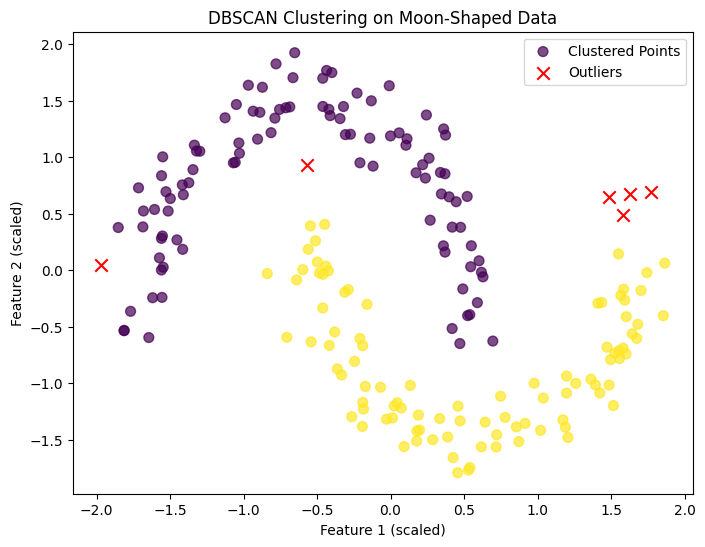

In [3]:
#ans Q8.

# Import libraries
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# Step 1: Generate moon-shaped synthetic data
X, y_true = make_moons(n_samples=200, noise=0.1, random_state=42)

# Step 2: Standardize the data (important for DBSCAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled)

# Step 4: Plot clusters and outliers
plt.figure(figsize=(8,6))

# Mask for core clusters (non-noise points)
core_points = y_dbscan != -1
noise_points = y_dbscan == -1

# Plot clusters
plt.scatter(X_scaled[core_points, 0], X_scaled[core_points, 1],
            c=y_dbscan[core_points], cmap='viridis', s=50, label='Clustered Points', alpha=0.7)

# Plot noise points (outliers)
plt.scatter(X_scaled[noise_points, 0], X_scaled[noise_points, 1],
            c='red', marker='x', s=80, label='Outliers')

plt.title("DBSCAN Clustering on Moon-Shaped Data")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.legend()
plt.show()


Q9. Load the Wine dataset, reduce it to 2D using PCA, then apply
Agglomerative Clustering and visualize the result in 2D with a scatter plot?

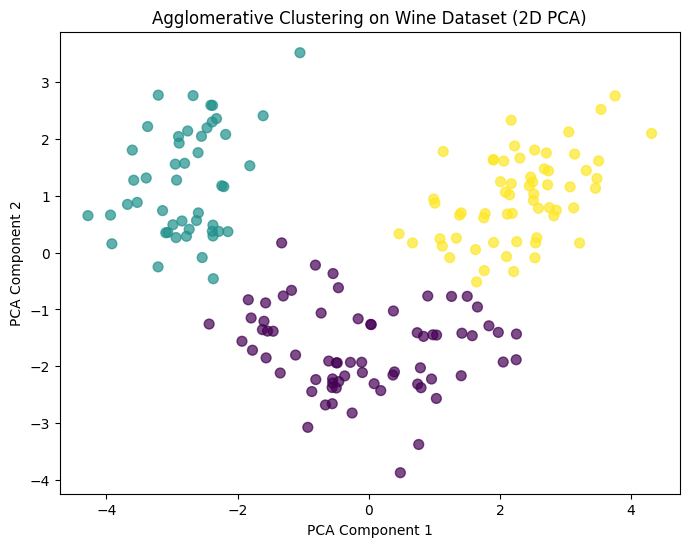

In [4]:
#Ans Q9.

# Import libraries
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# Step 1: Load Wine dataset
wine = load_wine()
X = wine.data

# Step 2: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Reduce to 2D using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Step 4: Apply Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=3)  # Wine dataset has 3 classes
y_agglo = agglo.fit_predict(X_pca)

# Step 5: Visualize clusters in 2D
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_agglo, cmap='viridis', s=50, alpha=0.7)
plt.title("Agglomerative Clustering on Wine Dataset (2D PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


Q10. You are working as a data analyst at an e-commerce company. The
marketing team wants to segment customers based on their purchasing behavior to run
targeted promotions. The dataset contains customer demographics and their product
purchase history across categories.
Describe your real-world data science workflow using clustering:
● Which clustering algorithm(s) would you use and why?
● How would you preprocess the data (missing values, scaling)?
● How would you determine the number of clusters?
● How would the marketing team benefit from your clustering analysis?
(Include your Python code and output in the code box below.)


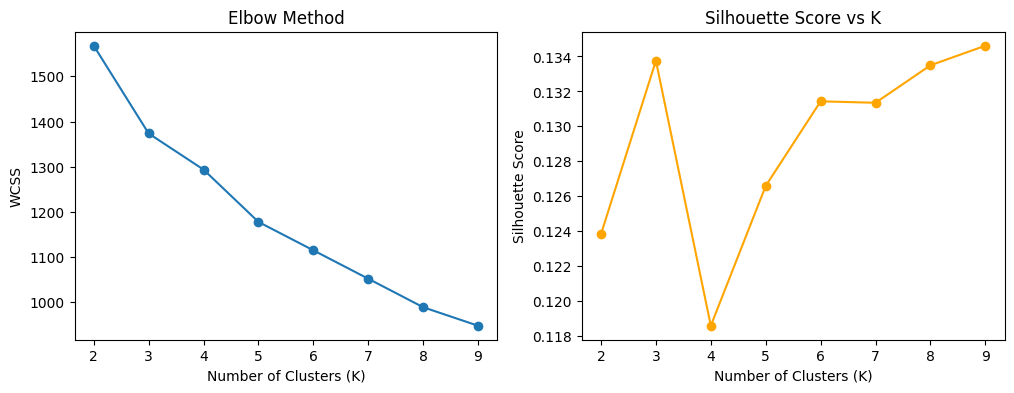

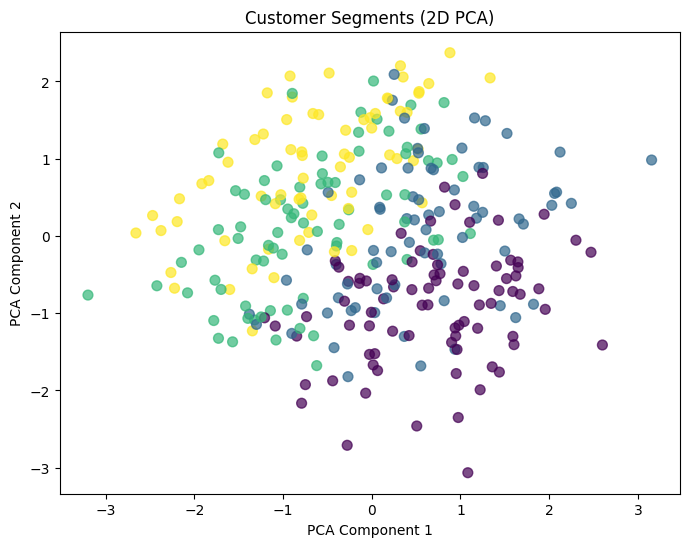

DBSCAN Clusters (excluding noise): 2
DBSCAN Noise Points: 35


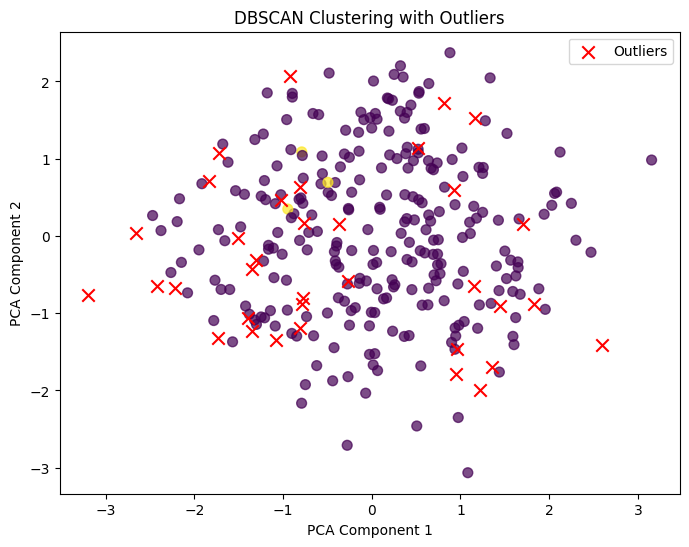

In [5]:
#Ans Q10

# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ------------------------------
# Step 1: Simulate a customer dataset
# ------------------------------
np.random.seed(42)
n_customers = 300

data = {
    'Age': np.random.randint(18, 65, n_customers),
    'Annual_Income': np.random.randint(20000, 150000, n_customers),
    'Electronics_Spend': np.random.randint(1000, 50000, n_customers),
    'Clothing_Spend': np.random.randint(500, 20000, n_customers),
    'Groceries_Spend': np.random.randint(1000, 25000, n_customers),
    'Purchase_Frequency': np.random.randint(1, 50, n_customers)
}

df = pd.DataFrame(data)

# ------------------------------
# Step 2: Handle missing values (example: fill NA with median)
# ------------------------------
df.fillna(df.median(), inplace=True)

# ------------------------------
# Step 3: Feature scaling
# ------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# ------------------------------
# Step 4: Determine optimal K using Elbow & Silhouette
# ------------------------------
wcss = []
sil_scores = []
K_range = range(2, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Plot WCSS (Elbow Method)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

# Plot Silhouette Scores
plt.subplot(1,2,2)
plt.plot(K_range, sil_scores, marker='o', color='orange')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

# ------------------------------
# Step 5: Apply K-Means with chosen K (e.g., 4)
# ------------------------------
kmeans_final = KMeans(n_clusters=4, random_state=42)
clusters = kmeans_final.fit_predict(X_scaled)
df['Cluster'] = clusters

# ------------------------------
# Step 6: Optional: Reduce to 2D for visualization
# ------------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', s=50, alpha=0.7)
plt.title("Customer Segments (2D PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# ------------------------------
# Step 7: Optional: Apply DBSCAN to detect outliers
# ------------------------------
dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = db_labels

# Count clusters excluding noise
n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)
print(f"DBSCAN Clusters (excluding noise): {n_db_clusters}")
print(f"DBSCAN Noise Points: {n_noise}")

# Optional: visualize DBSCAN clusters with outliers
plt.figure(figsize=(8,6))
core_mask = db_labels != -1
noise_mask = db_labels == -1
plt.scatter(X_pca[core_mask,0], X_pca[core_mask,1], c=db_labels[core_mask], cmap='viridis', s=50, alpha=0.7)
plt.scatter(X_pca[noise_mask,0], X_pca[noise_mask,1], c='red', marker='x', s=80, label='Outliers')
plt.title("DBSCAN Clustering with Outliers")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()
